In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.integrate import solve_ivp
from fput import fput_ode

In [3]:
np.random.seed(2)

x0 = 0.01 * np.random.randint(-20, 21, size=3)
p0 = 0.01 * np.random.randint(-20, 21, size=3)

x0 -= np.mean(x0)
p0 -= np.mean(p0)

y0 = np.stack((x0, p0), axis=1).flatten()

print(y0)

[ 0.19  0.05 -0.06  0.01 -0.13 -0.06]


In [4]:
alpha = 3
m = 1
# t_max = 40000
t_max = 20000

sol = solve_ivp(fput_ode, (0, t_max), y0, args=(alpha, m), method="DOP853", rtol=1e-10, atol=1e-12, dense_output=True)

In [5]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.519e-02 ...  2.000e+04  2.000e+04]
        y: [[ 1.900e-01  1.910e-01 ...  1.314e-01  1.517e-01]
            [ 5.000e-02  3.254e-02 ...  2.121e-01  1.768e-01]
            ...
            [-1.300e-01 -1.313e-01 ... -2.157e-02 -5.150e-02]
            [-6.000e-02 -4.270e-02 ... -2.962e-01 -2.762e-01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7fe4f81817f0>
 t_events: None
 y_events: None
     nfev: 2588531
     njev: 0
      nlu: 0

In [6]:
ts = np.linspace(0, t_max, 10001)
ys = sol.sol(ts).reshape((3, 2, -1))
xs = ys[:, 0, :]
ps = ys[:, 1, :]
xrs = np.roll(xs, -1, axis=0)
E = np.sum(0.5*(xrs - xs)**2 + alpha/3 * (xrs-xs)**3, axis=0) + 0.5 * np.sum(ps**2, axis=0)

In [7]:
# maximal energy deviation
maxde = np.max(np.abs(E-E[0]))

print(maxde)
print(maxde/E[0])

1.0146174414527032e-08
9.681464135999074e-08


In [8]:
# total momentum and its max deviation
P = np.sum(ps, axis=0)
maxdp = np.max(np.abs(P))
print(maxdp)

# center of mass and its max deviation
X = np.sum(xs, axis=0)
maxdx = np.max(np.abs(X))
print(maxdx)

1.3433698597964394e-14
2.5978774687018813e-11


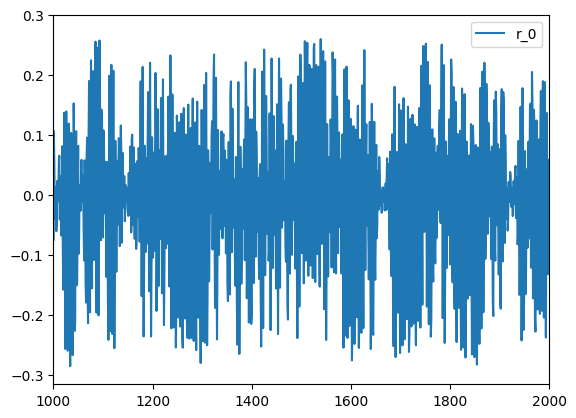

In [16]:
for i in range(1):
    plt.plot(ts, xs[i], label=f"r_{i}")
    # plt.plot(ts, ps[i], label=f"p_{i}")

plt.xlim(1000, 2000)

plt.legend()
plt.show()

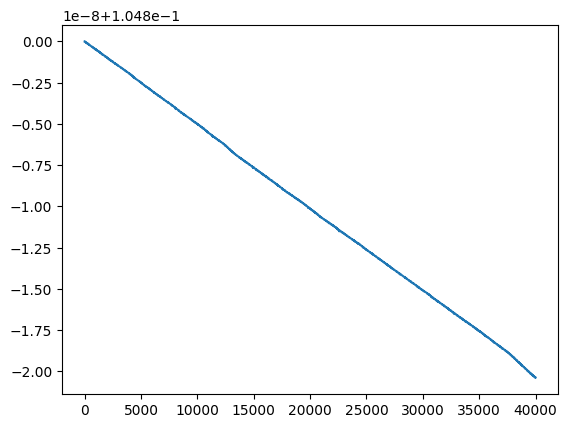

In [8]:
plt.plot(ts, E)
# plt.semilogy()
plt.show()

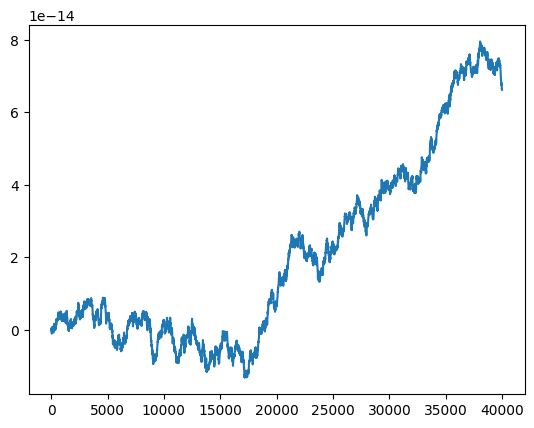

In [9]:
plt.plot(ts, np.sum(ps, axis=0))
# plt.semilogy()

Export samples

In [10]:
# at random intervals
ts = t_max*np.random.rand(50000)
ys = sol.sol(ts).transpose()
columns = "x1,p1,x2,p2,x3,p3".split(",")
df = pd.DataFrame(ys, columns=columns)
df["t"] = ts
df.to_csv("../data/fput_large.csv", index=False)